In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import scipy
import matplotlib.pyplot as plt

con = sqlite3.connect("customers.db")

cursor = con.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    id INTEGER PRIMARY KEY UNIQUE,
    name TEXT,
    city TEXT,
    age INTEGER
);
""")

sql = "INSERT OR IGNORE INTO customers (id, name, city, age) VALUES (?, ?, ?, ?)"

customers_data = [
    (1, "Ryan", "Los Angeles", 25),
    (2, "Jason", "Seattle", 20),
    (3, "Claire", "New York", 33),
    (4, "Karie", "Austin", 32),
    (5, "Jenny", "San Francisco", 23),
    (6, "Bryan", "New York", 40),
    (7, "Alice", "Miami", 35),
    (8, "James", "Chicago", 28)
]

cursor.executemany(sql, customers_data)
con.commit()

pd.read_sql("SELECT * FROM customers", con)

,id,name,city,age
0,1,Ryan,Los Angeles,25
1,2,Jason,Seattle,20
2,3,Claire,New York,33
3,4,Karie,Austin,32
4,5,Jenny,San Francisco,23
5,6,Bryan,New York,40
6,7,Alice,Miami,35
7,8,James,Chicago,28


In [2]:
df_names = pd.read_sql("""
SELECT name, age FROM customers
WHERE name LIKE "%an%"
ORDER BY name ASC
""", con)

In [3]:
df_names

,name,age
0,Bryan,40
1,Ryan,25


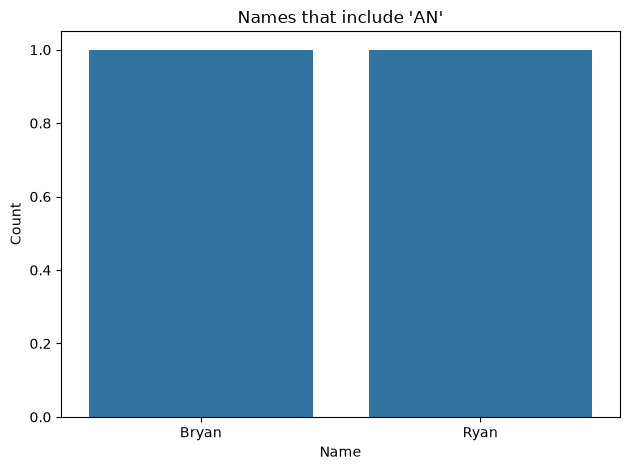

In [4]:
sns.countplot(data=df_names, x="name")
plt.title("Names that include 'AN'")
plt.xlabel("Name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
con.close()

Repo Address: https://github.com/yeonghwang-hub/cs82a-portfolio